<a href="https://colab.research.google.com/github/karenrosas0410-pixel/Estad-stica-2026B-/blob/main/Practica1U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 01 para series de tiempo

Para esta práctica, se utilizará la librería `yfinance`, la cual permite obtener datos históricos de mercados financieros directamente desde Yahoo Finance. Esta herramienta es de uso gratuito y no requiere el uso de claves de acceso (API keys), lo que la hace especialmente conveniente para fines educativos.

Los datos obtenidos mediante `yfinance` corresponden a información real del mercado financiero. Sin embargo, es importante considerar que esta herramienta no constituye una fuente oficial de datos, por lo que puede presentar limitaciones en cuanto a disponibilidad, consistencia o actualización. Para fines académicos y de análisis exploratorio, estos datos son adecuados; no obstante, para aplicaciones profesionales o decisiones financieras, se recomienda el uso de fuentes oficiales o servicios especializados.

Adicionalmente, `yfinance` no es una API oficial, por lo que en ocasiones puede presentar fallas temporales en la descarga de datos.

Los principales argumentos que requiere yfinance para realizar la descarga son:

+ `tickers`: Los tickers son identificadores únicos de activos financieros (por ejemplo, acciones) en los mercados. Por ejemplo, `AAPL` corresponde a Apple, `TSLA` a Tesla y `MSFT` a Microsoft. Si quieres inspeccionar tickers [pulsa aquí](https://www.nasdaq.com/market-activity/stocks/screener) y se te abrirá un catálogo de diversas multinacionales.
+ `start`: Fecha de inicio para la descarga de datos en formato `YYYY-mm-dd` que significa: cuatro dígitos para el año (`YYYY`), dos dígitos para el mes (`mm`) y dos dígitos para el día (`dd`) en ese orden.
+ `end`: Fecha de fin para la descarga de datos siguiendo también un formato `YYYY-mm-dd`.
+ `interval`: Define la frecuencia de los datos. Por ejemplo, `"1d"` indica datos diarios, `"1wk"` semanales y `"1mo"` mensuales.
+ `group_by`: Define la forma en que se organizan las columnas cuando se descargan datos de uno o varios tickers. Por ejemplo, `group_by="column"` organiza la información por tipo de variable (Open, High, Low, Close, etc.), mientras que `group_by="ticker"` agrupa primero por activo financiero.
+ `auto_adjust`: Si se establece en `True`, los precios se ajustan automáticamente considerando dividendos y divisiones de acciones. Si es `False`, se mantienen los valores originales.
+ `actions`: Permite incluir información adicional como dividendos y divisiones de acciones cuando se establece en `True`.
+ `progress`: Controla si se muestra o no una barra de progreso durante la descarga.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# Link para inspeccionar tickers:
# https://www.nasdaq.com/market-activity/stocks/screener

# Obtener datos de acciones
df = yf.download(
    tickers="AAPL",          # AAPL: Apple, TSLA: Tesla, MSFT: Microsoft, etc.
    start="2024-01-01",      # Fecha de inicio
    end="2026-04-01",        # Fecha de fin
    interval="1d",           # Intervalo de tiempo: 1 día
    group_by="column",       # Forma estándar de organizar las columnas
    auto_adjust=False,       # False conserva columnas como Close y Adj Close
    actions=False,           # True incluiría dividendos y divisiones de acciones
    progress=False           # Evita mostrar barra de progreso
)

# Verificar si la descarga fue exitosa
if df.empty:
    raise ValueError(
        "No se descargaron datos. Verifica que el ticker sea correcto "
        "o intenta nuevamente más tarde."
    )

# Paso 1: Mover 'Date' del índice a columna regular
df = df.reset_index()

# Paso 2: Aplanar columnas si vienen como MultiIndex
# Esto puede ocurrir dependiendo de la versión de yfinance/pandas.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(valor) for valor in columna if valor != ""]).strip()
        for columna in df.columns
    ]

# Reemplazar espacios por _
df.columns = [i.replace(" ", "_") for i in df.columns]

# Paso 3:
#######################################################
## En caso de que no se requiera la hora

# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df

,Date,Adj_Close_AAPL,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
0,2024-01-02,183.731308,185.639999,188.440002,183.889999,187.149994,82488700
1,2024-01-03,182.355591,184.250000,185.880005,183.429993,184.220001,58414500
2,2024-01-04,180.039658,181.910004,183.089996,180.880005,182.149994,71983600
3,2024-01-05,179.317184,181.179993,182.759995,180.169998,181.990005,62379700
4,2024-01-08,183.652130,185.559998,185.600006,181.500000,182.089996,59144500
...,...,...,...,...,...,...,...
558,2026-03-25,252.619995,252.619995,255.000000,251.600006,254.100006,28476700
559,2026-03-26,252.889999,252.889999,257.000000,250.770004,252.119995,41796700
560,2026-03-27,248.800003,248.800003,255.490005,248.070007,253.899994,47900000
561,2026-03-30,246.630005,246.630005,250.869995,245.509995,250.070007,39446200


Una vez extraida la información, tenemos un DataFrame con las siguientes variables:

+ `Date`: Fecha correspondiente a cada registro de la serie de tiempo.
+ `Open_AAPL`: Precio de apertura de la acción al inicio de la jornada.
+ `High_AAPL`: Precio máximo alcanzado por la acción durante el intervalo de tiempo seleccionado.
+ `Low_AAPL`: Precio mínimo registrado durante el intervalo de tiempo seleccionado.
+ `Close_AAPL`: Precio de cierre de la acción al final del intervalo de tiempo seleccionado.
+ `Adj_Close_AAPL`: Precio de cierre ajustado, el cual incorpora efectos de dividendos y divisiones de acciones, proporcionando una medida más consistente para análisis históricos.
+ `Volume_AAPL`: Número total de acciones negociadas durante el día (volumen de transacciones).

En las series de tiempo `x` siempre es la variable temporal, en esta caso `Date`, mientras que `y` puede ser cualquiera de las restantes, dependiendo de lo que se esté analizando. En este caso recomiendo usar `Adj_Close_APPL` debido a que es la que incorpora más información.

Primero se debe revisar el DataFrame para asegurarnos de que las variables son del tipo adecuado (sin variables tipo `object`).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            563 non-null    datetime64[ns]
 1   Adj_Close_AAPL  563 non-null    float64       
 2   Close_AAPL      563 non-null    float64       
 3   High_AAPL       563 non-null    float64       
 4   Low_AAPL        563 non-null    float64       
 5   Open_AAPL       563 non-null    float64       
 6   Volume_AAPL     563 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 30.9 KB


Ahora se declara `x` y `y`.

In [ ]:
x = df["Date"]
y = df['Adj_Close_AAPL']

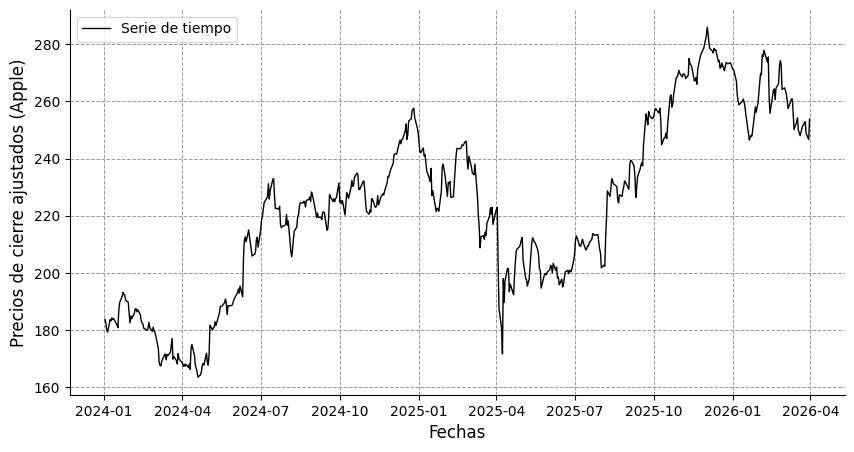

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustados (Apple)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



## Métodos de promedios móviles

**Ejercicio 1**: Aplica una media móvil simple (SMA) a la serie de tiempo. Prueba con distintos tamaños de ventana (`window`) y selecciona uno que consideres adecuado. Justifica tu elección con base en el comportamiento observado en la serie.

Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# Link para inspeccionar tickers:
# https://www.nasdaq.com/market-activity/stocks/screener

# Obtener datos de acciones
df = yf.download(
    tickers="AAPL",          # AAPL: Apple, TSLA: Tesla, MSFT: Microsoft, etc.
    start="2024-01-01",      # Fecha de inicio
    end="2026-04-01",        # Fecha de fin
    interval="1d",           # Intervalo de tiempo: 1 día
    group_by="column",       # Forma estándar de organizar las columnas
    auto_adjust=False,       # False conserva columnas como Close y Adj Close
    actions=False,           # True incluiría dividendos y divisiones de acciones
    progress=False           # Evita mostrar barra de progreso
)

# Verificar si la descarga fue exitosa
if df.empty:
    raise ValueError(
        "No se descargaron datos. Verifica que el ticker sea correcto "
        "o intenta nuevamente más tarde."
    )

# Paso 1: Mover 'Date' del índice a columna regular
df = df.reset_index()

# Paso 2: Aplanar columnas si vienen como MultiIndex
# Esto puede ocurrir dependiendo de la versión de yfinance/pandas.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(valor) for valor in columna if valor != ""]).strip()
        for columna in df.columns
    ]
# Reemplazar espacios por _
df.columns = [i.replace(" ", "_") for i in df.columns]

# Paso 3:
#######################################################
## En caso de que no se requiera la hora

# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df

,Date,Adj_Close_AAPL,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
0,2024-01-02,183.562180,185.639999,188.440002,183.889999,187.149994,82488700
1,2024-01-03,182.187775,184.250000,185.880005,183.429993,184.220001,58414500
2,2024-01-04,179.873917,181.910004,183.089996,180.880005,182.149994,71983600
3,2024-01-05,179.152100,181.179993,182.759995,180.169998,181.990005,62379700
4,2024-01-08,183.483078,185.559998,185.600006,181.500000,182.089996,59144500
...,...,...,...,...,...,...,...
558,2026-03-25,252.387466,252.619995,255.000000,251.600006,254.100006,28476700
559,2026-03-26,252.657227,252.889999,257.000000,250.770004,252.119995,41796700
560,2026-03-27,248.570984,248.800003,255.490005,248.070007,253.899994,47900000
561,2026-03-30,246.402985,246.630005,250.869995,245.509995,250.070007,39446200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            563 non-null    datetime64[ns]
 1   Adj_Close_AAPL  563 non-null    float64       
 2   Close_AAPL      563 non-null    float64       
 3   High_AAPL       563 non-null    float64       
 4   Low_AAPL        563 non-null    float64       
 5   Open_AAPL       563 non-null    float64       
 6   Volume_AAPL     563 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 30.9 KB


In [5]:
x=df["Date"]
y=df["Adj_Close_AAPL"]

In [6]:
df['Adj_Close_AAPL_SMA']=df['Adj_Close_AAPL'].rolling(window=160).mean()

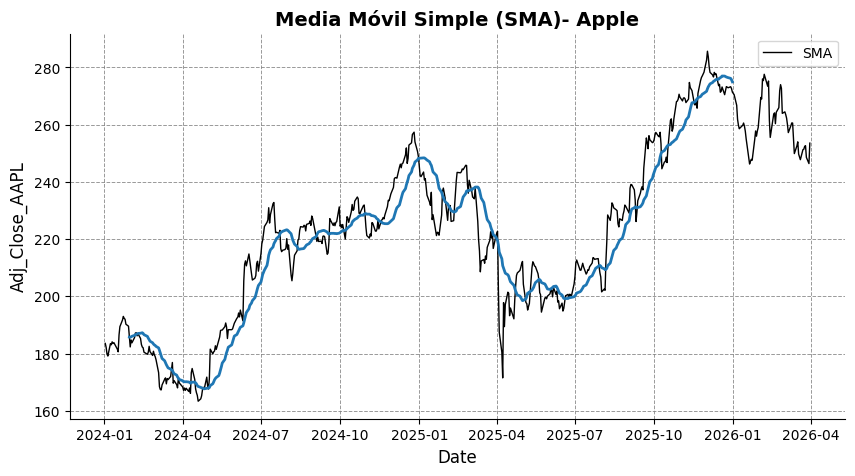

In [15]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SMA'
)

# --- Título ---
plt.title(
    'Media Móvil Simple (SMA)- Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Date',
    fontsize=12
)

plt.ylabel(
    'Adj_Close_AAPL',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
# Línea SMA
plt.plot(apple.index, apple['SMA_20'],
         label='SMA 20 días',
         linewidth=2)


## Método de suavisación exponencial

**Ejercicio 2**: Aplica una suavización exponencial simple (SES) a la serie de tiempo. Prueba con distintos valores del parámetro de suavizamiento (por ejemplo, mediante span o alpha) y selecciona uno que consideres adecuado. Justifica tu elección con base en el comportamiento observado en la serie.

Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [17]:
df['Adj_Close_AAPL_SES'] = df['Adj_Close_AAPL'].ewm(span=400, adjust=False).mean()

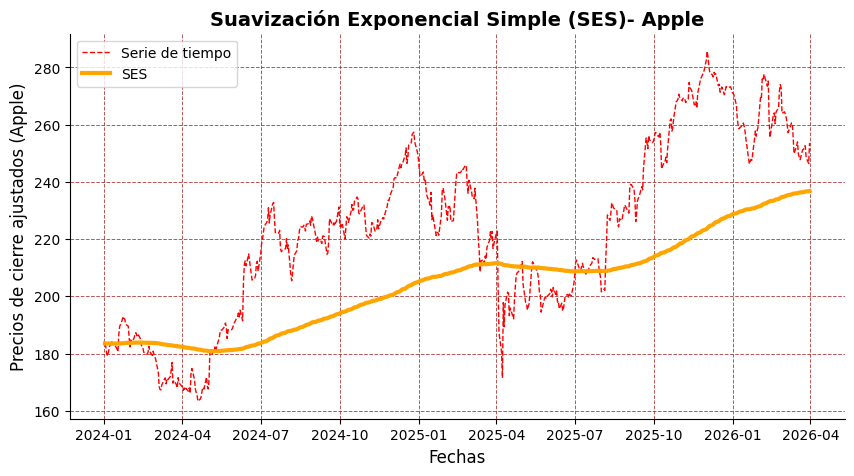

In [22]:
#@title import matplotlib.pyplot as plt
#Configuración general del gráfico
plt.figure(
      figsize=(10, 5), #tamaño de la figura (ancho, alto) en pulgadas
      dpi=100 #resolución del gráfico
      )
#Gráfico de línea
plt.plot(
       x, y,
       color='red', #color de la línea
       linewidth=1.0, #grosor de la línea
       linestyle='--', #estilo de línea
       marker='o', #marcador en cada punto
       markersize=0, #tamaño del marcador
       markerfacecolor='yellow',
       markeredgecolor='orange',
       label='Serie de tiempo'
       )
#ráfico de línea
plt.plot(
        x, df["Adj_Close_AAPL_SES"],
        color='orange', #color de la línea
        linewidth=3.0, #grosor de la línea
        linestyle='-', #estilo de línea
        marker='o', #marcador en cada punto
        markersize=0, #tamaño del marcador
        markerfacecolor='red',
        markeredgecolor='orange',
        label='SES' )
#Título
plt.title(
         'Suavización Exponencial Simple (SES)- Apple',
         fontsize=14,
         fontweight='bold' )
#Etiquetas de los ejes
plt.xlabel(
         'Fechas',
         fontsize=12
         )
plt.ylabel(
         'Precios de cierre ajustados (Apple)',
         fontsize=12
         )
#Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
#Márgenes
plt.margins(x=0.05, y=0.05) #espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) #derecha
plt.gca().spines['top'].set_visible(False) #superior

#Para eliminar márgenes completamente, usar: #plt.margins(0)
#Cuadrícula (opcional, pero didáctica)
plt.grid(
        visible=True,
        linestyle='--',
        linewidth=0.7,
        alpha=0.8, color="brown"
        )
#Leyenda
plt.legend(
          fontsize=10,
          loc='best',
          frameon=True
          )

**Ejercicio 3**: Observando las curvas por SMA y SES, señala las ventajas y desventajas que puedes observar en ambos gráficos.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

Ventajas

nos ayuda a reducir el ruido y a observar la tendencia general

Desventajas SMA

tiene una reaccion lenta con los cambios

Vnetajas SES

Tiene una reaccion mas rapida a los cambios

Desventajas

Si no se ajusta al parametro puede seguirse el ruido


## Tendencias no lineales

**Ejercicio 4**: Realiza una regresión polinomial de grado 2. Usa series de Fourier para extraer la estacionalidad y calcular el ruido de medición. Apóyate en los gráficos correspondientes y analiza las longitudes de onda para establecer si existe estacionalidad. Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [24]:
from numpy.polynomial.polynomial import Polynomial
X= pd.to_datetime(df["Date"]).map(pd.Timestamp.timestamp)
grado=2
modelo=Polynomial.fit(X, y, deg = grado)
df['tendencia_polinomial'] = modelo(X)
df['ruido_polinomial'] = y- df['tendencia_polinomial']

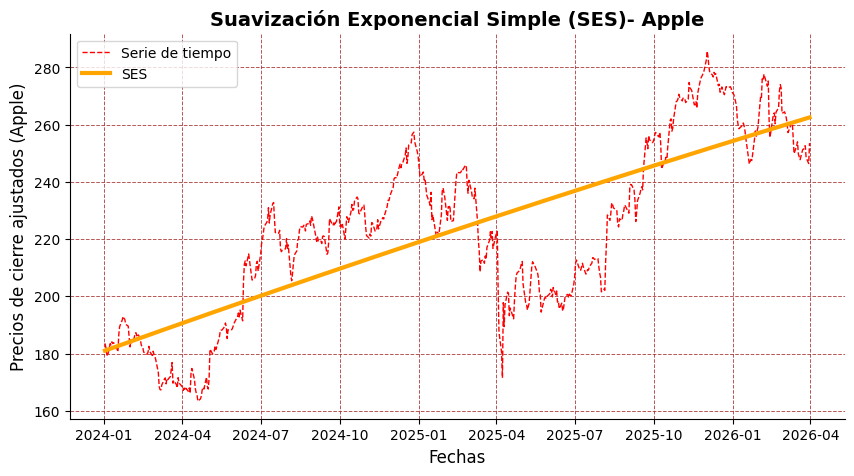

In [27]:
#@title import matplotlib.pyplot as plt
#Configuración general del gráfico
plt.figure(
      figsize=(10, 5), #tamaño de la figura (ancho, alto) en pulgadas
      dpi=100 #resolución del gráfico
      )
#Gráfico de línea
plt.plot(
       x, y,
       color='red', #color de la línea
       linewidth=1.0, #grosor de la línea
       linestyle='--', #estilo de línea
       marker='o', #marcador en cada punto
       markersize=0, #tamaño del marcador
       markerfacecolor='yellow',
       markeredgecolor='orange',
       label='Serie de tiempo'
       )
#ráfico de línea
plt.plot(
        x, df["tendencia_polinomial"],
        color='orange', #color de la línea
        linewidth=3.0, #grosor de la línea
        linestyle='-', #estilo de línea
        marker='o', #marcador en cada punto
        markersize=0, #tamaño del marcador
        markerfacecolor='blue',
        markeredgecolor='orange',
        label='SES' )
#Título
plt.title(
         'Suavización Exponencial Simple (SES)- Apple',
         fontsize=14,
         fontweight='bold' )
#Etiquetas de los ejes
plt.xlabel(
         'Fechas',
         fontsize=12
         )
plt.ylabel(
         'Precios de cierre ajustados (Apple)',
         fontsize=12
         )
#Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
#Márgenes
plt.margins(x=0.05, y=0.05) #espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) #derecha
plt.gca().spines['top'].set_visible(False) #superior

#Para eliminar márgenes completamente, usar: #plt.margins(0)
#Cuadrícula (opcional, pero didáctica)
plt.grid(
        visible=True,
        linestyle='--',
        linewidth=0.7,
        alpha=0.8, color="brown"
        )
#Leyenda
plt.legend(
          fontsize=10,
          loc='best',
          frameon=True
          )

In [33]:
def Transformada_de_Fourier(serie, terminos, un_grafico):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    from scipy.fftpack import fft, ifft
    n = len(serie)
    transformada_fourier = fft(serie)
    frecuencias = np.fft.fftfreq(n)
    componentes = pd.DataFrame({
        'frecuencia': frecuencias,
        'magnitud': np.abs(transformada_fourier),
        'longitud_de_onda': 1 / frecuencias
    })

    componentes = componentes.sort_values(by='magnitud', ascending=False)
    top_frecuencias = componentes.loc[componentes['frecuencia'] > 0].nlargest(terminos, 'magnitud')
    top_frecuencias.reset_index(drop=True, inplace=True)
    print("Frecuencias principales:\n", top_frecuencias)
    t = np.arange(n)
    plt.figure(figsize=(12, 4))
    componente_temporal_sumado = np.zeros_like(serie)
    componentes_temporales = []
    n=0
    for i, row in top_frecuencias.iterrows():
        n+=1

        fourier_component = np.zeros_like(transformada_fourier)
        idx = np.where(frecuencias == row['frecuencia'])[0][0] # índice de la frecuencia en la FFT
        fourier_component[idx] = transformada_fourier[idx] # mantener solo la frecuencia positiva
        fourier_component[-idx] = transformada_fourier[-idx] # mantener la frecuencia negativa correspondiente
        if n == (terminos+1):
            break
        componente_temporal = ifft(fourier_component).real
        componentes_temporales.append(componente_temporal)
        componente_temporal_sumado += componente_temporal
        plt.plot(
            componente_temporal,
            label=f'Longitud de onda {1 / row["frecuencia"]:.0f}',
            alpha=1, linewidth = 0.5,
        )
    plt.title('Componentes de Fourier de la Serie')
    plt.xlabel('Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid()
    plt.show()
    return componente_temporal_sumado

Frecuencias principales:
    frecuencia     magnitud  longitud_de_onda
0    0.003552  6063.451869        281.500000
1    0.001776  2339.006266        563.000000
2    0.005329  1757.612511        187.666667
3    0.008881  1617.547246        112.600000
4    0.007105  1566.066553        140.750000


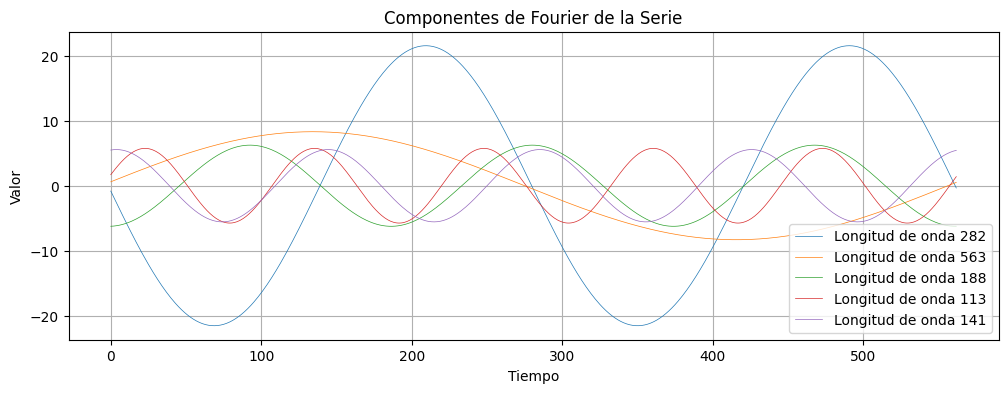

In [34]:
serie = df['ruido_polinomial'].values
terminos = 5
un_grafico = False
cts = Transformada_de_Fourier(serie, terminos, un_grafico)
df["estacionalidad_polinomial"] = cts

In [35]:
df["ruido_final"] =(
     df["Adj_Close_AAPL"]
     -df["tendencia_polinomial"]
     -df["estacionalidad_polinomial"]
     )

## Análisis de los componentes de la serie

**Ejercicio 5**: Apóyate de los gráficos correspondientes para analizar cada uno de los componentes de la serie por separado. Comenta lo que se puede observar de cada componente, si crees que se pudo aproximar bien o no, y por qué.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

Tendencia: Representan el comportamiento general a un  largo plazo. la tendenciaes 18ascendente nos puede muestra crecimiento en el tiempo.

Estacionalidad: Son patrones que se repiten periódicamente. Por lo que existen algunas repeticiones y ciclos y puede que esten relacionados con reportes financieros o temporadas de ventas.

Ruido: Son variaciones aleatorias o inesperadas: Por lo que el ruido contiene cambios bruscos dificiles de predecir y puede deberse a noticias,m rumores o eventos economicos.

## Análisis fundamental (ligero)

**Ejercicio 6**: Realiza una interpretación de los componentes de la serie de tiempo (tendencia, estacionalidad y ruido).

En tu análisis:

+ Explica qué factores externos podrían justificar la tendencia observada (por ejemplo: crecimiento de la empresa, cambios en el mercado, decisiones estratégicas, etc.).
+ Identifica posibles eventos o situaciones que expliquen los patrones de estacionalidad.
+ Reflexiona sobre el ruido, indicando qué tipo de eventos inesperados o aleatorios podrían estar representados en este componente.

Este análisis no requiere un estudio exhaustivo del entorno económico, pero sí una interpretación razonada, similar a un análisis fundamental básico.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

En la serie de tiempo de Aple se puede observar una tendencia de crecimiento, aunque en algunas bajadas temporales, esto puede deberse al crecimiento de la empresa, nuevos productos o nuevos cambios en le mercado.

la estacionalidad puede relacionarse con temporadas de ventas o lanzamientos de productos

El ruido representa cambios inesperados causados por noticiasz, economia o eventos imprevistos

## Aplicaciones

**Ejercicio 7**: Analiza qué personas, empresas o instituciones podrían beneficiarse del análisis realizado.

En tu respuesta:

+ Menciona al menos tres actores (por ejemplo: inversionistas, empresas, instituciones financieras, gobierno, etc.).
+ Explica cómo utilizarían este tipo de análisis.
+ Describe qué beneficios concretos podrían obtener.

Adicionalmente, reflexiona sobre cómo un análisis más profundo podría mejorar estos beneficios o ampliar sus aplicaciones.

Relaciona tu respuesta con los resultados obtenidos en tu análisis (tendencia, estacionalidad y ruido).

Una vez termines, borra estas instrucciones y redacta tus observaciones.

Este analisis puede beneficiar a los invrsionistas ya que les ayuda a decir cuando comprar o vender acciones a las instituciones financieras para poder analizar el mercado y a Apple para poder conocer el impacto de sus decisiones.